# EDA_Lupa_Konsumsi_Obat

Notebook ini berfokus pada analisis **risiko lupa konsumsi obat** dan **kebutuhan reminder** sebagai dasar fitur pengingat minum obat dan family monitoring pada aplikasi Teman Pulih.

## Fokus masalah bisnis

Latar belakang utama yang dianalisis pada notebook ini adalah kasus pasien yang lupa minum obat atau membutuhkan bantuan pengingat. Analisis ini tidak dimaksudkan untuk mendiagnosis pasien, tetapi untuk memahami pola data yang mendukung kebutuhan fitur produk.

Referensi latar belakang:
- Jones et al. (2015), *The inability of older adults to recall their drugs and medical conditions*: https://pubmed.ncbi.nlm.nih.gov/25829296/
- Dataset survey: `MULTI DIMENSIONAL ADHERENCE DATASET IN SOUTHEAST NIGERIA.xlsx`
- Questionnaire pendukung: `MULTI-DIMENSIONAL PATIENTS DATASETS QUESTIONNAIRE (1).docx`


## 1. Business Questions

EDA ini menjawab pertanyaan bisnis berikut:

1. **Berapa proporsi pasien yang pernah lupa minum obat sesuai resep?**
2. **Seberapa besar pasien mengalami kesulitan mengingat jadwal konsumsi obat?**
3. **Apa penyebab paling umum pasien melewatkan konsumsi obat?**
4. **Apa sumber pengingat obat yang paling sering digunakan pasien?**
5. **Apakah pasien dengan beban obat lebih tinggi lebih membutuhkan reminder?**
6. **Apakah caregiver dan akses mobile phone mendukung implementasi reminder digital dan family monitoring?**

Output utama notebook:
- Data wrangling untuk variabel lupa obat/reminder.
- Feature engineering `reminder_need_score` dan `reminder_need_segment`.
- Visualisasi dan explanatory analysis untuk kebutuhan reminder.
- Dataset bersih untuk dashboard Streamlit.


## 2. Import Library

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')
DEFAULT_COLOR = sns.color_palette('deep')[0]

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11


## 3. Konfigurasi Path Dataset

Sesuaikan folder dataset dengan lokasi di komputer lokal. Notebook ini sudah diarahkan ke folder:

`D:\Icun\Dicoding\DBS Coding Camp\Capstone Project\Dataset`

Jika notebook dijalankan di lingkungan lain, kode akan mencoba fallback ke folder kerja saat ini atau `/mnt/data`.


In [2]:
DATASET_FILENAME = 'MULTI DIMENSIONAL ADHERENCE DATASET IN SOUTHEAST NIGERIA.xlsx'

DATASET_DIR_WINDOWS = Path(r'D:\Icun\Dicoding\DBS Coding Camp\Capstone Project\Dataset')

candidate_paths = [
    DATASET_DIR_WINDOWS / DATASET_FILENAME,
    Path.cwd() / DATASET_FILENAME,
    Path('/mnt/data') / DATASET_FILENAME,
]

DATASET_PATH = None
for path in candidate_paths:
    if path.exists():
        DATASET_PATH = path
        break

if DATASET_PATH is None:
    searched = '\n'.join(str(p) for p in candidate_paths)
    raise FileNotFoundError(
        'Dataset tidak ditemukan. Pastikan file Excel berada di salah satu path berikut:\n' + searched
    )

print('Dataset ditemukan di:', DATASET_PATH)


Dataset ditemukan di: D:\Icun\Dicoding\DBS Coding Camp\Capstone Project\Dataset\MULTI DIMENSIONAL ADHERENCE DATASET IN SOUTHEAST NIGERIA.xlsx


## 4. Validasi Dependency Excel

Bagian ini memastikan library `openpyxl` tersedia. Library ini dibutuhkan `pandas` untuk membaca file `.xlsx`.


In [3]:
import sys
import subprocess
import importlib.util

if importlib.util.find_spec('openpyxl') is None:
    print('openpyxl belum terinstall. Menginstall openpyxl pada environment Python yang sedang dipakai...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'openpyxl'])
else:
    print('openpyxl sudah tersedia.')

import openpyxl
print('Versi openpyxl:', openpyxl.__version__)


openpyxl sudah tersedia.
Versi openpyxl: 3.1.5


## 4. Load Dataset

In [4]:
df_raw = pd.read_excel(DATASET_PATH, sheet_name='Sheet1', engine='openpyxl')

print('Dimensi dataset:', df_raw.shape)
display(df_raw.head())


Dimensi dataset: (609, 70)


,S/N,GENDER,AGE,Marital Status,Religion Affiliation,Educational Attainment,Occupation,How many hours do work in a day,Who is your care giver,Do you have a mobile phone,How often do you receive text messages/alerts in a day,How often do you answer phone calls in a day,What is your preferred communication language,Health Condition,How long have you been taking your drugs,Number of drugs prescribed,How many tablets do you take in a day,When do you take your drugs,Why do you choose to take your drugs at that time,19,20,21,TOTAL,PERCEPTION LEVEL,Unnamed: 24,22,23,24,TOTAL.1,SPSS,BEHAVIOUR LEVEL,25,26,Unnamed: 33,27,28,29,TOTAL,SPSS.1,Unnamed: 39,Unnamed: 40,30,31,32,TOTAL.2,SPSS.2,KNOWLEDGE LEVEL,Unnamed: 47,33,34,35,36,37,38,39,40,TOTAL.3,NON ADHERENT LEVEL,Unnamed: 58,41,42,43,44,45,46,47,48,49,50,51
0,1,female,31-40,married,Christianity,university first degreee,Professional,8 hours,Spouse,Yes,Very Often,Very Often,English,Mental,NaN,two,two,in the morning at a set time,It is easier to remember,2.0,1.0,2.0,5.0,BAD PERCEPTION,NaN,2.0,1.0,4.0,7.0,3.0,MODERATELY FORGETFUL,change in my daily route,self,NaN,5.0,2.0,3.0,10.0,2,MODERATELY POSITIVE,NaN,3.0,5.0,5.0,13.0,3.0,GOOD,NaN,1.0,1,0.0,1.0,0.0,1.0,1.0,1,6.0,MEDIUM ADHERENT,NaN,4.0,5.0,5.0,1.0,4.0,5.0,4.0,1.0,4.0,5.0,0
1,2,male,31-40,married,Christianity,WASC/SSCE,Trader,24 hours,Parent,Yes,Rarely,Very Often,English,Diabetes,Above a year,one,one,during breakfast,Doctor told me to take it at that time,2.0,1.0,2.0,5.0,BAD PERCEPTION,NaN,4.0,3.0,3.0,10.0,4.0,HIGHLY FORGETFUL,drugs disturb me,self,NaN,4.0,4.0,3.0,11.0,3,HIGHLY POSITIVE,NaN,1.0,5.0,4.0,10.0,2.0,MODERATE,NaN,0.0,0,0.0,0.0,0.0,0.0,0.0,1,1.0,LOW ADHERENT,NaN,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,1
2,3,female,Above 50,widow/widower,Christianity,FLSC,Farmer,8 hours,Children,Yes,Quit Often,Quit Often,Igbo,NaN,Above a year,Above three,Above three,during breakfast,Doctor told me to take it at that time,2.0,3.0,3.0,8.0,FAIR PERCEPTION,NaN,1.0,0.0,0.0,1.0,1.0,NOT FORGETFUL,other specify,self,NaN,4.0,5.0,4.0,13.0,3,HIGHLY POSITIVE,NaN,2.0,5.0,4.0,11.0,3.0,GOOD,NaN,0.0,0,1.0,1.0,0.0,1.0,1.0,1,5.0,MEDIUM ADHERENT,NaN,5.0,2.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,1
3,4,female,31-40,married,Christianity,university first degreee,Trader,12 hours,Spouse,Yes,Quit Often,Quit Often,English,HIV,NaN,one,two,during breakfast,It is easier to remember,3.0,4.0,3.0,10.0,GOOD PERCEPTION,NaN,4.0,4.0,4.0,12.0,4.0,HIGHLY FORGETFUL,simply forget,self,NaN,4.0,2.0,5.0,11.0,3,HIGHLY POSITIVE,NaN,4.0,5.0,5.0,14.0,3.0,GOOD,NaN,0.0,0,0.0,0.0,1.0,0.0,0.0,1,2.0,LOW ADHERENT,NaN,5.0,5.0,5.0,5.0,5.0,4.0,5.0,4.0,4.0,5.0,1
4,5,female,41-50,married,Christianity,WASC/SSCE,Farmer,8 hours,Spouse,NaN,Quit Often,Quit Often,Igbo,Mental,Above a year,Above three,Above three,during breakfast,Doctor told me to take it at that time,3.0,3.0,3.0,9.0,FAIR PERCEPTION,NaN,4.0,4.0,4.0,12.0,4.0,HIGHLY FORGETFUL,other specify,self,NaN,4.0,5.0,4.0,13.0,3,HIGHLY POSITIVE,NaN,2.0,4.0,3.0,9.0,2.0,MODERATE,NaN,0.0,0,0.0,0.0,0.0,1.0,1.0,1,3.0,MEDIUM ADHERENT,NaN,5.0,5.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0,0


## 5. Data Understanding dan Data Dictionary Awal

Beberapa kolom pada dataset menggunakan nomor pertanyaan dari questionnaire. Untuk EDA ini, kolom-kolom bernomor tersebut dipetakan ulang menjadi nama variabel yang lebih mudah dibaca.


In [5]:
data_dictionary = pd.DataFrame([
    {'kolom_asli': '22', 'nama_baru': 'forget_planned_activity', 'makna': 'Seberapa sering lupa melakukan hal yang sudah direncanakan'},
    {'kolom_asli': '23', 'nama_baru': 'forget_recent_information', 'makna': 'Seberapa sering lupa informasi yang baru diberitahu'},
    {'kolom_asli': '24', 'nama_baru': 'miss_appointment_without_reminder', 'makna': 'Seberapa sering melewatkan janji jika tidak diingatkan'},
    {'kolom_asli': '25', 'nama_baru': 'reason_missed_drug', 'makna': 'Alasan biasanya melewatkan obat'},
    {'kolom_asli': '26', 'nama_baru': 'medication_reminder_source', 'makna': 'Sumber pengingat waktu dan dosis obat'},
    {'kolom_asli': '33', 'nama_baru': 'forget_take_drug', 'makna': 'Kadang lupa minum obat sesuai resep'},
    {'kolom_asli': '36', 'nama_baru': 'forget_bring_drug_travel', 'makna': 'Lupa membawa obat saat bepergian atau keluar rumah'},
    {'kolom_asli': '40', 'nama_baru': 'difficulty_remembering_drug', 'makna': 'Kesulitan mengingat untuk minum obat'},
    {'kolom_asli': '41', 'nama_baru': 'people_forget_drug_statement', 'makna': 'Persetujuan bahwa orang kadang lupa minum obat sesuai resep'},
    {'kolom_asli': '42', 'nama_baru': 'possible_forget_time_dose_frequency', 'makna': 'Persetujuan bahwa orang bisa lupa waktu, jumlah, dan frekuensi obat'},
    {'kolom_asli': '44', 'nama_baru': 'alert_call_sms_help', 'makna': 'Alert, voice call, IVR, USSD membantu minum obat sesuai anjuran'},
    {'kolom_asli': '45', 'nama_baru': 'motivational_message_help', 'makna': 'Pesan persuasif/motivasi/edukasi membantu kepatuhan obat'},
    {'kolom_asli': '50', 'nama_baru': 'stakeholder_adopt_app', 'makna': 'Healthcare provider, caregiver, dan pasien perlu mengadopsi layanan reminder'},
    {'kolom_asli': '51', 'nama_baru': 'accept_mobile_app', 'makna': 'Penerimaan penggunaan mobile app service'},
])

display(data_dictionary)


,kolom_asli,nama_baru,makna
0,22,forget_planned_activity,Seberapa sering lupa melakukan hal yang sudah ...
1,23,forget_recent_information,Seberapa sering lupa informasi yang baru diber...
2,24,miss_appointment_without_reminder,Seberapa sering melewatkan janji jika tidak di...
3,25,reason_missed_drug,Alasan biasanya melewatkan obat
4,26,medication_reminder_source,Sumber pengingat waktu dan dosis obat
5,33,forget_take_drug,Kadang lupa minum obat sesuai resep
6,36,forget_bring_drug_travel,Lupa membawa obat saat bepergian atau keluar r...
7,40,difficulty_remembering_drug,Kesulitan mengingat untuk minum obat
8,41,people_forget_drug_statement,Persetujuan bahwa orang kadang lupa minum obat...
9,42,possible_forget_time_dose_frequency,"Persetujuan bahwa orang bisa lupa waktu, jumla..."


## 6. Assessing Data

Tahap ini mengecek dimensi data, missing value, duplikasi, dan nilai unik pada kolom yang relevan untuk EDA lupa obat.


In [6]:
print('Jumlah baris:', df_raw.shape[0])
print('Jumlah kolom:', df_raw.shape[1])
print('Jumlah duplikasi:', df_raw.duplicated().sum())

missing_summary = (
    df_raw.isna().sum()
    .reset_index()
    .rename(columns={'index': 'column', 0: 'missing_count'})
)
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df_raw) * 100).round(2)
missing_summary = missing_summary.sort_values('missing_count', ascending=False)

display(missing_summary.head(20))


Jumlah baris: 609
Jumlah kolom: 70
Jumlah duplikasi: 0


,column,missing_count,missing_pct
58,Unnamed: 58,609,100.00
40,Unnamed: 40,609,100.00
33,Unnamed: 33,609,100.00
47,Unnamed: 47,609,100.00
24,Unnamed: 24,609,100.00
38,SPSS.1,452,74.22
30,BEHAVIOUR LEVEL,452,74.22
29,SPSS,452,74.22
45,SPSS.2,452,74.22
46,KNOWLEDGE LEVEL,452,74.22


In [7]:
important_cols = [
    'GENDER', 'AGE', 'Who is your care giver', 'Do you have a mobile phone',
    'How often do you receive text messages/alerts in a day',
    'How often do you answer phone calls in a day',
    'Health Condition', 'Number of drugs prescribed', 'How many tablets do you take in a day',
    22, 23, 24, 25, 26, 33, 36, 40, 41, 42, 44, 45, 50, 51,
    'BEHAVIOUR LEVEL', 'NON ADHERENT LEVEL'
]

for col in important_cols:
    if col in df_raw.columns:
        print('\n' + '=' * 80)
        print('Kolom:', col)
        display(df_raw[col].value_counts(dropna=False).head(30).to_frame('count'))



Kolom: GENDER


,count
GENDER,
female,331
male,278



Kolom: AGE


,count
AGE,
Above 50,250
41-50,169
31-40,69
21-30,53
21-31,41
BELOW 21,18
NaN,4
41-50,3
21,1



Kolom: Who is your care giver


...

,count
51,
1,393
NaN,151
0,64
1`,1



Kolom: BEHAVIOUR LEVEL


,count
BEHAVIOUR LEVEL,
NaN,452
MODERATELY FORGETFUL,56
HIGHLY FORGETFUL,46
FORGETFUL,38
NOT FORGETFUL,17



Kolom: NON ADHERENT LEVEL


,count
NON ADHERENT LEVEL,
NaN,452
MEDIUM ADHERENT,99
LOW ADHERENT,47
HIGH NON-ADHERENT,10
HIGH ADHERENT,1


### Catatan Assessing Data

- Kolom `33`, `36`, dan `40` menjadi indikator utama lupa obat/kesulitan mengingat obat.
- Kolom `25` dan `26` berbentuk teks bebas sehingga perlu standardisasi kategori.
- Kolom `22`, `23`, dan `24` menggunakan skala frekuensi 0 sampai 4.
- Beberapa kolom memiliki variasi penulisan seperti huruf besar/kecil, typo, dan kategori yang perlu digabung.


## 7. Data Cleaning

Tahap cleaning dilakukan untuk:

1. Mengganti nama kolom bernomor menjadi nama variabel yang informatif.
2. Membersihkan teks kategori.
3. Menggabungkan kategori yang memiliki makna sama.
4. Mengubah jawaban Yes/No dan skala tertentu menjadi fitur numerik.


In [8]:
df = df_raw.copy()

rename_cols = {
    22: 'forget_planned_activity',
    23: 'forget_recent_information',
    24: 'miss_appointment_without_reminder',
    25: 'reason_missed_drug',
    26: 'medication_reminder_source',
    33: 'forget_take_drug',
    36: 'forget_bring_drug_travel',
    40: 'difficulty_remembering_drug',
    41: 'people_forget_drug_statement',
    42: 'possible_forget_time_dose_frequency',
    44: 'alert_call_sms_help',
    45: 'motivational_message_help',
    46: 'educational_message_help',
    47: 'risk_message_help',
    48: 'cost_benefit_mobile_app',
    49: 'provider_discussion_app',
    50: 'stakeholder_adopt_app',
    51: 'accept_mobile_app'
}

df = df.rename(columns=rename_cols)

def clean_text(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    value = ' '.join(value.split())
    if value in ['nan', 'none', 'nil', '']:
        return np.nan
    return value

text_columns = [
    'GENDER', 'AGE', 'Marital Status', 'Educational Attainment', 'Occupation',
    'Who is your care giver', 'Do you have a mobile phone',
    'How often do you receive text messages/alerts in a day',
    'How often do you answer phone calls in a day',
    'Health Condition', 'How long have you been taking your drugs',
    'Number of drugs prescribed', 'How many tablets do you take in a day',
    'When do you take your drugs', 'Why do you choose to take your drugs at that time',
    'reason_missed_drug', 'medication_reminder_source',
    'BEHAVIOUR LEVEL', 'NON ADHERENT LEVEL'
]

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].apply(clean_text)

print('Cleaning awal selesai.')


Cleaning awal selesai.


In [9]:
# Standardisasi demografi dan kategori dasar

def normalize_gender(value):
    value = clean_text(value)
    if value in ['male', 'm']:
        return 'Male'
    if value in ['female', 'f']:
        return 'Female'
    return np.nan


def normalize_age(value):
    value = clean_text(value)
    if value in ['below 21', '21']:
        return 'Below 21'
    if value in ['21-30', '21-31']:
        return '21-30'
    if value in ['31-40']:
        return '31-40'
    if value in ['41-50', '4--50']:
        return '41-50'
    if value in ['above 50']:
        return 'Above 50'
    return np.nan


def normalize_yes_no(value):
    if pd.isna(value):
        return np.nan
    raw = str(value).strip().lower().replace('`', '')
    if raw in ['1', '1.0', 'yes', 'y']:
        return 1
    if raw in ['0', '0.0', 'no', 'n']:
        return 0
    return np.nan


def normalize_frequency_text(value):
    value = clean_text(value)
    if pd.isna(value):
        return np.nan
    mapping = {
        'very often': 'Very Often',
        'quit often': 'Quite Often',
        'quite often': 'Quite Often',
        'sometimes': 'Sometimes',
        'rarely': 'Rarely',
        'never': 'Never'
    }
    return mapping.get(value, value.title())


def normalize_drug_count(value):
    value = clean_text(value)
    if pd.isna(value):
        return np.nan
    mapping = {
        'none': 0,
        'nil': 0,
        'one': 1,
        'two': 2,
        'three': 3,
        'above three': 4
    }
    if value in mapping:
        return mapping[value]
    try:
        return int(float(value))
    except ValueError:
        return np.nan


def normalize_caregiver(value):
    value = clean_text(value)
    if pd.isna(value):
        return 'Unknown'
    if any(k in value for k in ['spouse', 'husband', 'wife']):
        return 'Spouse'
    if any(k in value for k in ['child', 'children', 'son', 'daughter']):
        return 'Children'
    if any(k in value for k in ['parent', 'mother', 'father']):
        return 'Parent'
    if any(k in value for k in ['relative', 'reltive', 'sister', 'brother']):
        return 'Relatives'
    if 'self' in value:
        return 'Self'
    if 'other' in value:
        return 'Others'
    return 'Others'


df['gender_clean'] = df['GENDER'].apply(normalize_gender)
df['age_group'] = df['AGE'].apply(normalize_age)
df['caregiver_group'] = df['Who is your care giver'].apply(normalize_caregiver).fillna('Unknown').astype(str)
df['has_mobile_phone'] = df['Do you have a mobile phone'].apply(normalize_yes_no)
df['sms_alert_frequency'] = df['How often do you receive text messages/alerts in a day'].apply(normalize_frequency_text)
df['call_answer_frequency'] = df['How often do you answer phone calls in a day'].apply(normalize_frequency_text)
df['number_of_drugs_num'] = df['Number of drugs prescribed'].apply(normalize_drug_count)
df['tablets_per_day_num'] = df['How many tablets do you take in a day'].apply(normalize_drug_count)

print('Standardisasi kategori dasar selesai.')


Standardisasi kategori dasar selesai.


In [10]:
# Standardisasi alasan melewatkan obat

def categorize_reason_missed(value):
    value = clean_text(value)
    if pd.isna(value):
        return 'Unknown'
    if 'forgot' in value or 'forget' in value:
        return 'Simply forgot'
    if 'reminder' in value or 'reeminder' in value:
        return 'Missed reminder'
    if 'work' in value or 'weork' in value:
        return 'Work related'
    if 'routine' in value or 'route' in value:
        return 'Change in routine'
    if 'felt better' in value:
        return 'Felt better'
    if 'felt worse' in value:
        return 'Felt worse'
    if 'disturb' in value or 'disturbs' in value:
        return 'Drug side effects/disturbance'
    if 'financial' in value:
        return 'Financial constraint'
    if 'never' in value or 'nothing' in value:
        return 'No specific reason'
    if 'other' in value:
        return 'Other/unclear'
    return 'Other/unclear'


def categorize_reminder_source(value):
    value = clean_text(value)
    if pd.isna(value):
        return 'Unknown'
    if 'self' in value or 'myself' in value:
        return 'Self reminder'
    if any(k in value for k in ['spouse', 'wife', 'husband', 'child', 'children', 'son', 'parent', 'mother', 'father', 'brother', 'sister', 'relative', 'reltive', 'friend']):
        return 'Family/caregiver'
    if 'alarm' in value or 'alarms' in value:
        return 'Alarm'
    if any(k in value for k in ['food', 'meal', 'breakfast', 'lunch', 'dinner']):
        return 'Meal/routine'
    if any(k in value for k in ['time', 'prescription', 'as prescribed', 'disease', 'condition', 'drug distinguish']):
        return 'Health routine/medicine cue'
    if 'none' in value:
        return 'No reminder'
    return 'Other/unclear'


df['reason_missed_drug_group'] = df['reason_missed_drug'].apply(categorize_reason_missed)
df['reminder_source_group'] = df['medication_reminder_source'].apply(categorize_reminder_source)

print('Standardisasi alasan dan sumber reminder selesai.')


Standardisasi alasan dan sumber reminder selesai.


In [11]:
# Konversi indikator utama lupa obat dan reminder

for col in ['forget_take_drug', 'forget_bring_drug_travel', 'difficulty_remembering_drug', 'accept_mobile_app']:
    if col in df.columns:
        df[col + '_binary'] = df[col].apply(normalize_yes_no)

# Skala frekuensi section B: 0=Never, 1=Rarely, 2=Sometimes, 3=Quite Often, 4=Very Often
frequency_map = {
    0: 'Never',
    1: 'Rarely',
    2: 'Sometimes',
    3: 'Quite Often',
    4: 'Very Often'
}

for col in ['forget_planned_activity', 'forget_recent_information', 'miss_appointment_without_reminder']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col + '_label'] = df[col].map(frequency_map)

# Likert app support: 1=Strongly Disagree sampai 5=Strongly Agree berdasarkan questionnaire.
likert_cols = [
    'people_forget_drug_statement', 'possible_forget_time_dose_frequency',
    'alert_call_sms_help', 'motivational_message_help', 'educational_message_help',
    'risk_message_help', 'cost_benefit_mobile_app', 'provider_discussion_app', 'stakeholder_adopt_app'
]

for col in likert_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col + '_agree_flag'] = np.where(df[col] >= 4, 1, np.where(df[col].notna(), 0, np.nan))

print('Konversi indikator selesai.')


Konversi indikator selesai.


## 8. Feature Engineering

Fitur turunan yang dibuat:

- `forget_med_flag`: pasien pernah lupa minum obat sesuai resep.
- `travel_forget_flag`: pasien lupa membawa obat saat bepergian.
- `external_reminder_needed`: pasien cenderung melewatkan janji jika tidak diingatkan.
- `memory_difficulty_flag`: pasien mengalami kesulitan mengingat konsumsi obat.
- `high_general_forgetfulness_flag`: indikator lupa aktivitas atau informasi baru minimal pada level Sometimes.
- `reminder_need_score`: skor gabungan kebutuhan reminder.
- `reminder_need_segment`: segmentasi kebutuhan reminder.


In [12]:
df['forget_med_flag'] = df['forget_take_drug_binary']
df['travel_forget_flag'] = df['forget_bring_drug_travel_binary']
df['memory_difficulty_flag'] = df['difficulty_remembering_drug_binary']

# Threshold >= 2 berarti Sometimes, Quite Often, atau Very Often.
df['external_reminder_needed'] = np.where(
    df['miss_appointment_without_reminder'].notna(),
    (df['miss_appointment_without_reminder'] >= 2).astype(int),
    np.nan
)

df['high_general_forgetfulness_flag'] = np.where(
    df[['forget_planned_activity', 'forget_recent_information']].notna().any(axis=1),
    ((df['forget_planned_activity'] >= 2) | (df['forget_recent_information'] >= 2)).astype(int),
    np.nan
)

score_cols = [
    'forget_med_flag',
    'travel_forget_flag',
    'memory_difficulty_flag',
    'external_reminder_needed',
    'high_general_forgetfulness_flag'
]

df['reminder_need_score'] = df[score_cols].sum(axis=1, skipna=True)

def segment_reminder_need(score):
    if pd.isna(score):
        return np.nan
    if score <= 1:
        return 'Low Reminder Need'
    if score <= 3:
        return 'Medium Reminder Need'
    return 'High Reminder Need'

segment_order = ['Low Reminder Need', 'Medium Reminder Need', 'High Reminder Need']
df['reminder_need_segment'] = pd.Categorical(
    df['reminder_need_score'].apply(segment_reminder_need),
    categories=segment_order,
    ordered=True
)

feature_summary = df[score_cols + ['reminder_need_score', 'reminder_need_segment']].head()
display(feature_summary)


,forget_med_flag,travel_forget_flag,memory_difficulty_flag,external_reminder_needed,high_general_forgetfulness_flag,reminder_need_score,reminder_need_segment
0,1.0,1.0,1.0,1.0,1.0,5.0,High Reminder Need
1,0.0,0.0,1.0,1.0,1.0,3.0,Medium Reminder Need
2,0.0,1.0,1.0,0.0,0.0,2.0,Medium Reminder Need
3,0.0,0.0,1.0,1.0,1.0,3.0,Medium Reminder Need
4,0.0,0.0,1.0,1.0,1.0,3.0,Medium Reminder Need


In [13]:
print('Distribusi reminder_need_score')
display(df['reminder_need_score'].value_counts(dropna=False).sort_index().to_frame('count'))

print('Distribusi reminder_need_segment')
display(df['reminder_need_segment'].value_counts(dropna=False).reindex(segment_order).to_frame('count'))


Distribusi reminder_need_score


,count
reminder_need_score,
0.0,11
1.0,27
2.0,170
3.0,213
4.0,146
5.0,42


Distribusi reminder_need_segment


,count
reminder_need_segment,
Low Reminder Need,38
Medium Reminder Need,383
High Reminder Need,188


## 9. Dataset Khusus EDA Lupa Konsumsi Obat

In [14]:
selected_cols = [
    'S/N', 'gender_clean', 'age_group', 'Marital Status', 'Educational Attainment', 'Occupation',
    'caregiver_group', 'has_mobile_phone', 'sms_alert_frequency', 'call_answer_frequency',
    'Health Condition', 'How long have you been taking your drugs',
    'number_of_drugs_num', 'tablets_per_day_num',
    'When do you take your drugs', 'Why do you choose to take your drugs at that time',
    'forget_planned_activity', 'forget_planned_activity_label',
    'forget_recent_information', 'forget_recent_information_label',
    'miss_appointment_without_reminder', 'miss_appointment_without_reminder_label',
    'reason_missed_drug_group', 'reminder_source_group',
    'forget_med_flag', 'travel_forget_flag', 'memory_difficulty_flag',
    'external_reminder_needed', 'high_general_forgetfulness_flag',
    'reminder_need_score', 'reminder_need_segment',
    'BEHAVIOUR LEVEL', 'NON ADHERENT LEVEL',
    'people_forget_drug_statement_agree_flag', 'possible_forget_time_dose_frequency_agree_flag',
    'alert_call_sms_help_agree_flag', 'motivational_message_help_agree_flag',
    'stakeholder_adopt_app_agree_flag', 'accept_mobile_app_binary'
]

eda_df = df[[col for col in selected_cols if col in df.columns]].copy()

print('Dimensi data EDA:', eda_df.shape)
display(eda_df.head())


Dimensi data EDA: (609, 39)


,S/N,gender_clean,age_group,Marital Status,Educational Attainment,Occupation,caregiver_group,has_mobile_phone,sms_alert_frequency,call_answer_frequency,Health Condition,How long have you been taking your drugs,number_of_drugs_num,tablets_per_day_num,When do you take your drugs,Why do you choose to take your drugs at that time,forget_planned_activity,forget_planned_activity_label,forget_recent_information,forget_recent_information_label,miss_appointment_without_reminder,miss_appointment_without_reminder_label,reason_missed_drug_group,reminder_source_group,forget_med_flag,travel_forget_flag,memory_difficulty_flag,external_reminder_needed,high_general_forgetfulness_flag,reminder_need_score,reminder_need_segment,BEHAVIOUR LEVEL,NON ADHERENT LEVEL,people_forget_drug_statement_agree_flag,possible_forget_time_dose_frequency_agree_flag,alert_call_sms_help_agree_flag,motivational_message_help_agree_flag,stakeholder_adopt_app_agree_flag,accept_mobile_app_binary
0,1,Female,31-40,married,university first degreee,professional,Spouse,1.0,Very Often,Very Often,mental,NaN,2.0,2.0,in the morning at a set time,it is easier to remember,2.0,Sometimes,1.0,Rarely,4.0,Very Often,Change in routine,Self reminder,1.0,1.0,1.0,1.0,1.0,5.0,High Reminder Need,moderately forgetful,medium adherent,1.0,1.0,0.0,1.0,1.0,0.0
1,2,Male,31-40,married,wasc/ssce,trader,Parent,1.0,Rarely,Very Often,diabetes,above a year,1.0,1.0,during breakfast,doctor told me to take it at that time,4.0,Very Often,3.0,Quite Often,3.0,Quite Often,Drug side effects/disturbance,Self reminder,0.0,0.0,1.0,1.0,1.0,3.0,Medium Reminder Need,highly forgetful,low adherent,1.0,1.0,1.0,1.0,1.0,1.0
2,3,Female,Above 50,widow/widower,flsc,farmer,Children,1.0,Quite Often,Quite Often,NaN,above a year,4.0,4.0,during breakfast,doctor told me to take it at that time,1.0,Rarely,0.0,Never,0.0,Never,Other/unclear,Self reminder,0.0,1.0,1.0,0.0,0.0,2.0,Medium Reminder Need,not forgetful,medium adherent,1.0,0.0,1.0,1.0,1.0,1.0
3,4,Female,31-40,married,university first degreee,trader,Spouse,1.0,Quite Often,Quite Often,hiv,NaN,1.0,2.0,during breakfast,it is easier to remember,4.0,Very Often,4.0,Very Often,4.0,Very Often,Simply forgot,Self reminder,0.0,0.0,1.0,1.0,1.0,3.0,Medium Reminder Need,highly forgetful,low adherent,1.0,1.0,1.0,1.0,1.0,1.0
4,5,Female,41-50,married,wasc/ssce,farmer,Spouse,NaN,Quite Often,Quite Often,mental,above a year,4.0,4.0,during breakfast,doctor told me to take it at that time,4.0,Very Often,4.0,Very Often,4.0,Very Often,Other/unclear,Self reminder,0.0,0.0,1.0,1.0,1.0,3.0,Medium Reminder Need,highly forgetful,medium adherent,1.0,1.0,1.0,1.0,1.0,0.0


## 10. Helper Function untuk Visualisasi

In [15]:
def add_bar_labels(ax, percent=False):
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if pd.isna(value):
                labels.append('')
            elif percent:
                labels.append(f'{value:.1f}%')
            else:
                labels.append(f'{int(value)}')
        ax.bar_label(container, labels=labels, padding=3)


def plot_count(series, title, xlabel='', ylabel='Jumlah Pasien', order=None, horizontal=False, top_n=None):
    counts = series.value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order).dropna()
    if top_n is not None:
        counts = counts.head(top_n)
    plt.figure(figsize=(10, 5))
    if horizontal:
        ax = counts.sort_values().plot(kind='barh')
        ax.set_xlabel(ylabel)
        ax.set_ylabel(xlabel)
    else:
        ax = counts.plot(kind='bar')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        plt.xticks(rotation=30, ha='right')
        add_bar_labels(ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return counts


def percent_table(series):
    output = pd.concat([
        series.value_counts(dropna=False).rename('count'),
        (series.value_counts(dropna=False, normalize=True) * 100).round(2).rename('percentage')
    ], axis=1)
    return output


# EDA dan Explanatory Analysis

## BQ1. Berapa proporsi pasien yang pernah lupa minum obat sesuai resep?

,count,percentage
forget_med_flag,,
Tidak lupa,327,53.69
Pernah lupa,265,43.51
NaN,17,2.79


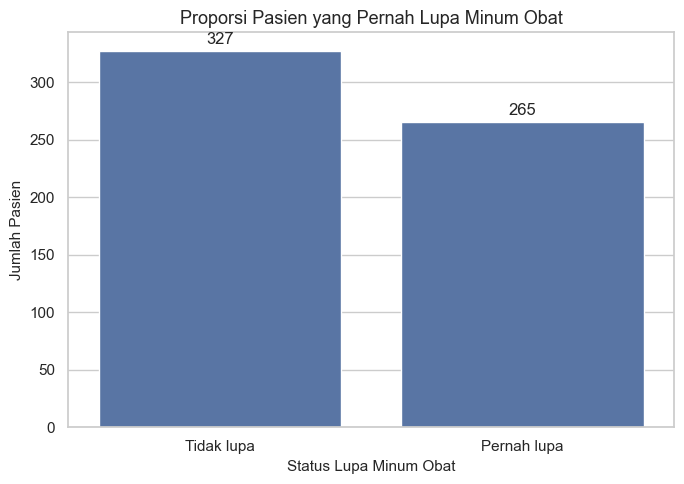

In [16]:
forget_table = percent_table(eda_df['forget_med_flag'].map({0: 'Tidak lupa', 1: 'Pernah lupa'}))
display(forget_table)

plt.figure(figsize=(7, 5))
ax = sns.countplot(
    data=eda_df,
    x=eda_df['forget_med_flag'].map({0: 'Tidak lupa', 1: 'Pernah lupa'}),
    order=['Tidak lupa', 'Pernah lupa'],
    color=DEFAULT_COLOR
)
ax.set_title('Proporsi Pasien yang Pernah Lupa Minum Obat')
ax.set_xlabel('Status Lupa Minum Obat')
ax.set_ylabel('Jumlah Pasien')
add_bar_labels(ax)
plt.tight_layout()
plt.show()


**Interpretasi:**

Grafik ini menunjukkan seberapa besar pasien yang melaporkan pernah lupa minum obat sesuai resep. Jika proporsi pasien yang pernah lupa cukup besar, maka fitur reminder obat memiliki justifikasi kuat sebagai fitur utama aplikasi.

## BQ2. Seberapa besar pasien mengalami kesulitan mengingat jadwal konsumsi obat?

,count,percentage
memory_difficulty_flag,,
Kesulitan mengingat,407,66.83
Tidak kesulitan,167,27.42
NaN,35,5.75


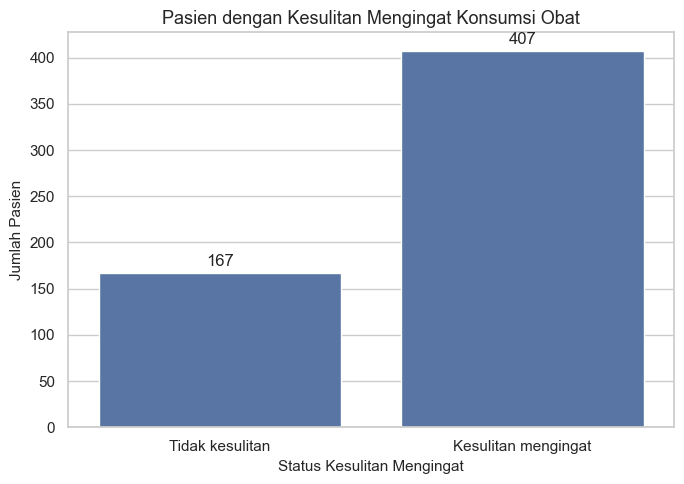

In [17]:
memory_table = percent_table(eda_df['memory_difficulty_flag'].map({0: 'Tidak kesulitan', 1: 'Kesulitan mengingat'}))
display(memory_table)

plt.figure(figsize=(7, 5))
ax = sns.countplot(
    data=eda_df,
    x=eda_df['memory_difficulty_flag'].map({0: 'Tidak kesulitan', 1: 'Kesulitan mengingat'}),
    order=['Tidak kesulitan', 'Kesulitan mengingat'],
    color=DEFAULT_COLOR
)
ax.set_title('Pasien dengan Kesulitan Mengingat Konsumsi Obat')
ax.set_xlabel('Status Kesulitan Mengingat')
ax.set_ylabel('Jumlah Pasien')
add_bar_labels(ax)
plt.tight_layout()
plt.show()


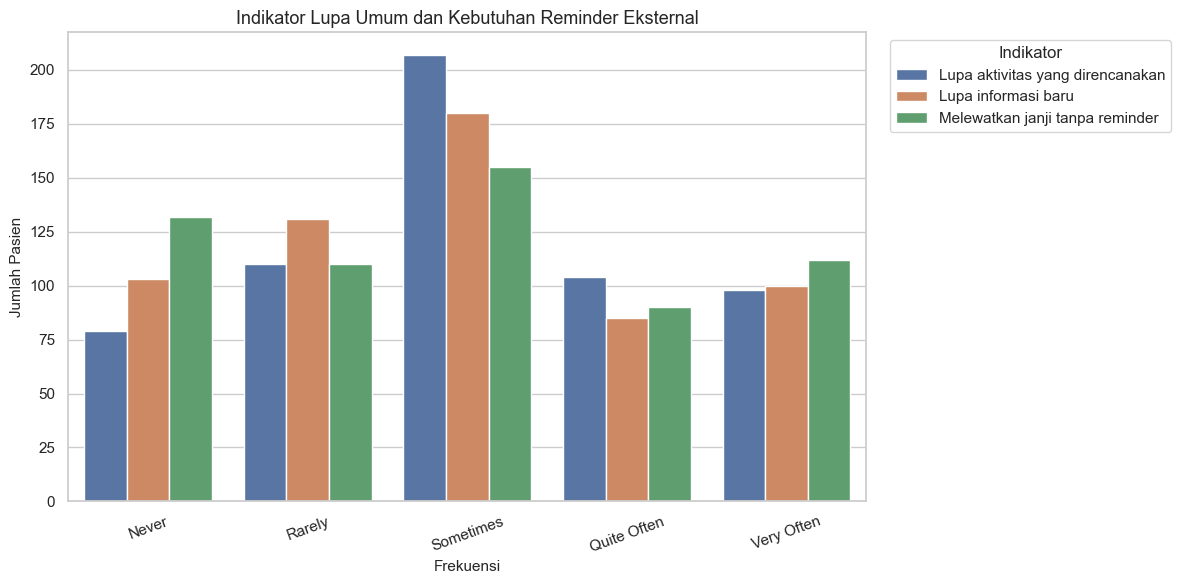

In [18]:
frequency_order = ['Never', 'Rarely', 'Sometimes', 'Quite Often', 'Very Often']

fig_data = eda_df.melt(
    value_vars=['forget_planned_activity_label', 'forget_recent_information_label', 'miss_appointment_without_reminder_label'],
    var_name='indicator',
    value_name='frequency'
)

indicator_labels = {
    'forget_planned_activity_label': 'Lupa aktivitas yang direncanakan',
    'forget_recent_information_label': 'Lupa informasi baru',
    'miss_appointment_without_reminder_label': 'Melewatkan janji tanpa reminder'
}
fig_data['indicator'] = fig_data['indicator'].map(indicator_labels)
fig_data['frequency'] = pd.Categorical(fig_data['frequency'], categories=frequency_order, ordered=True)

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=fig_data, x='frequency', hue='indicator', order=frequency_order)
ax.set_title('Indikator Lupa Umum dan Kebutuhan Reminder Eksternal')
ax.set_xlabel('Frekuensi')
ax.set_ylabel('Jumlah Pasien')
plt.xticks(rotation=20)
plt.legend(title='Indikator', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Interpretasi:**

Analisis ini menunjukkan apakah pasien memiliki kecenderungan lupa secara umum dan apakah mereka bergantung pada reminder eksternal. Indikator ini penting karena pasien yang sering lupa aktivitas atau informasi baru berpotensi membutuhkan reminder obat yang lebih terstruktur.

## BQ3. Apa penyebab paling umum pasien melewatkan konsumsi obat?

,count
reason_missed_drug_group,
Simply forgot,110
Drug side effects/disturbance,87
Unknown,82
Felt better,81
Change in routine,63
Work related,60
Missed reminder,55
Other/unclear,54
Felt worse,14


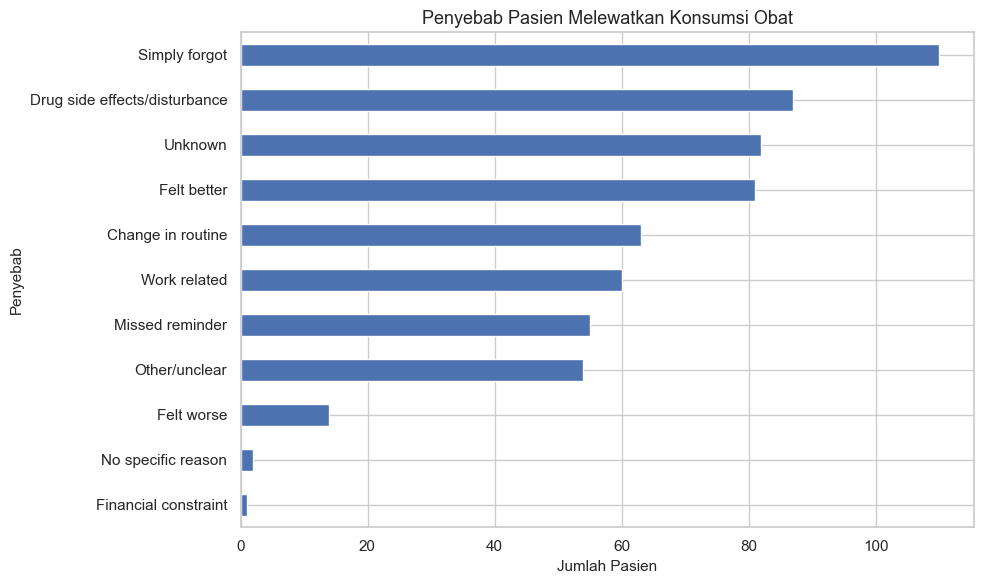

In [19]:
reason_counts = eda_df['reason_missed_drug_group'].fillna('Unknown').astype(str).value_counts()
display(reason_counts.to_frame('count'))

plt.figure(figsize=(10, 6))
ax = reason_counts.sort_values().plot(kind='barh')
ax.set_title('Penyebab Pasien Melewatkan Konsumsi Obat')
ax.set_xlabel('Jumlah Pasien')
ax.set_ylabel('Penyebab')
plt.tight_layout()
plt.show()


**Interpretasi:**

Jika kategori seperti `Simply forgot`, `Missed reminder`, atau `Change in routine` muncul dominan, maka masalah obat terlewat berkaitan langsung dengan kebutuhan reminder. Hasil ini dapat digunakan untuk merancang reminder berulang atau fallback notification ketika pasien belum menandai obat sebagai diminum.

## BQ4. Apa sumber pengingat obat yang paling sering digunakan pasien?

,count
reminder_source_group,
Self reminder,297
Family/caregiver,151
Unknown,74
Other/unclear,33
Health routine/medicine cue,22
Alarm,21
Meal/routine,11


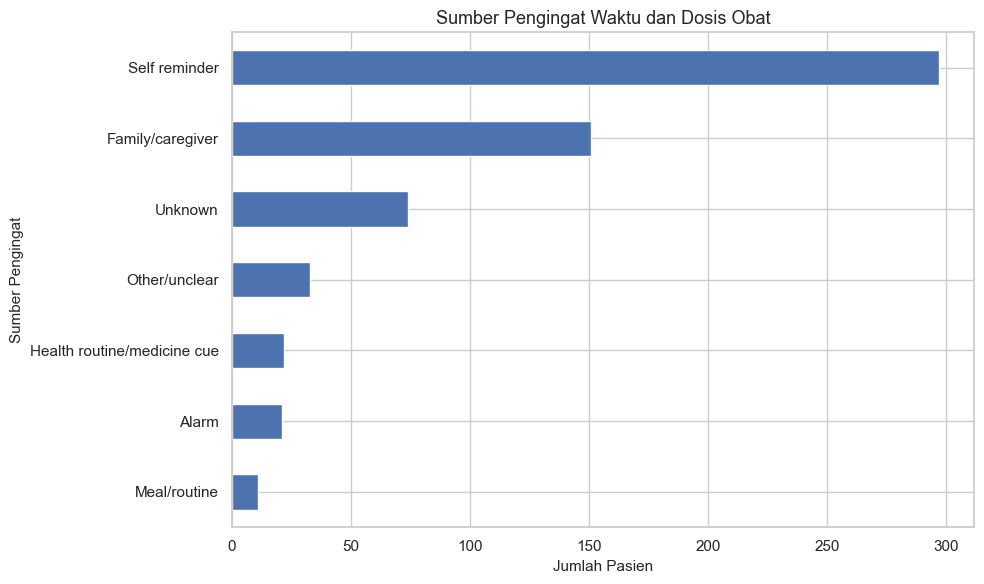

In [20]:
reminder_counts = eda_df['reminder_source_group'].fillna('Unknown').astype(str).value_counts()
display(reminder_counts.to_frame('count'))

plt.figure(figsize=(10, 6))
ax = reminder_counts.sort_values().plot(kind='barh')
ax.set_title('Sumber Pengingat Waktu dan Dosis Obat')
ax.set_xlabel('Jumlah Pasien')
ax.set_ylabel('Sumber Pengingat')
plt.tight_layout()
plt.show()


**Interpretasi:**

Jika banyak pasien masih mengandalkan diri sendiri, keluarga, caregiver, atau alarm, maka aplikasi Teman Pulih dapat memperkuat mekanisme pengingat melalui notifikasi digital dan family monitoring. Family monitoring relevan ketika sumber pengingat utama berasal dari keluarga/caregiver.

## BQ5. Apakah pasien dengan beban obat lebih tinggi lebih membutuhkan reminder?

,number_of_drugs_count,tablets_per_day_count
1.0,46.0,87
2.0,150.0,179
3.0,181.0,111
4.0,218.0,210
6.0,NaN,1
NaN,14.0,21


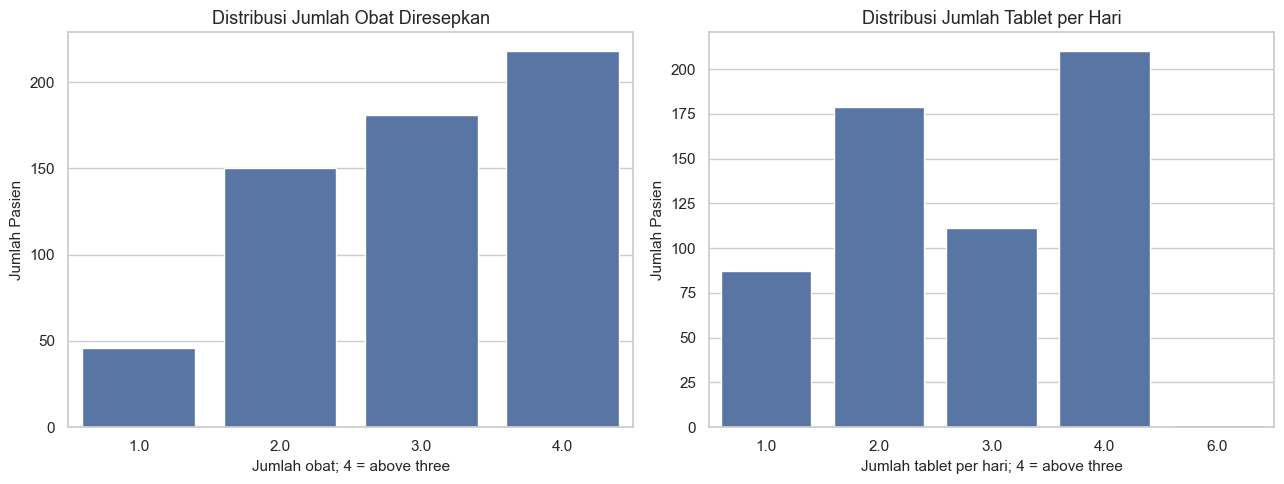

In [21]:
drug_burden_table = pd.DataFrame({
    'number_of_drugs_count': eda_df['number_of_drugs_num'].value_counts(dropna=False).sort_index(),
    'tablets_per_day_count': eda_df['tablets_per_day_num'].value_counts(dropna=False).sort_index()
})
display(drug_burden_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=eda_df, x='number_of_drugs_num', ax=axes[0], color=DEFAULT_COLOR)
axes[0].set_title('Distribusi Jumlah Obat Diresepkan')
axes[0].set_xlabel('Jumlah obat; 4 = above three')
axes[0].set_ylabel('Jumlah Pasien')

sns.countplot(data=eda_df, x='tablets_per_day_num', ax=axes[1], color=DEFAULT_COLOR)
axes[1].set_title('Distribusi Jumlah Tablet per Hari')
axes[1].set_xlabel('Jumlah tablet per hari; 4 = above three')
axes[1].set_ylabel('Jumlah Pasien')

plt.tight_layout()
plt.show()


reminder_need_segment,Low Reminder Need,Medium Reminder Need,High Reminder Need
number_of_drugs_num,,,
1.0,8.70,60.87,30.43
2.0,6.00,60.00,34.00
3.0,5.52,65.19,29.28
4.0,5.50,63.76,30.73


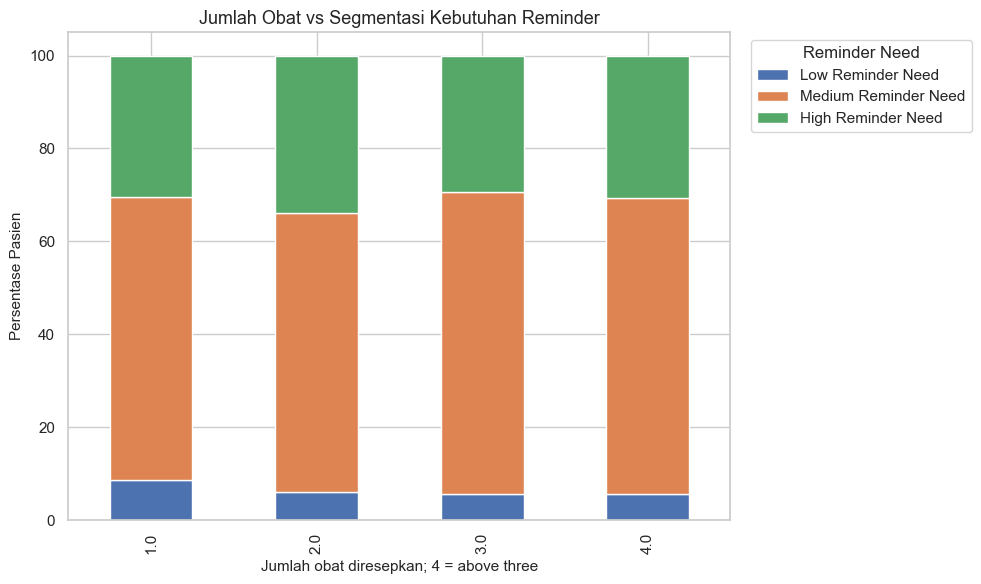

In [22]:
reminder_order = ['Low Reminder Need', 'Medium Reminder Need', 'High Reminder Need']

ct_drugs = pd.crosstab(
    eda_df['number_of_drugs_num'],
    eda_df['reminder_need_segment'],
    normalize='index'
).reindex(columns=reminder_order) * 100

display(ct_drugs.round(2))

ax = ct_drugs.plot(kind='bar', stacked=True, figsize=(10, 6))
ax.set_title('Jumlah Obat vs Segmentasi Kebutuhan Reminder')
ax.set_xlabel('Jumlah obat diresepkan; 4 = above three')
ax.set_ylabel('Persentase Pasien')
ax.legend(title='Reminder Need', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


reminder_need_segment,Low Reminder Need,Medium Reminder Need,High Reminder Need
tablets_per_day_num,,,
1.0,4.60,64.37,31.03
2.0,5.59,63.69,30.73
3.0,9.91,58.56,31.53
4.0,4.29,64.29,31.43
6.0,0.00,0.00,100.00


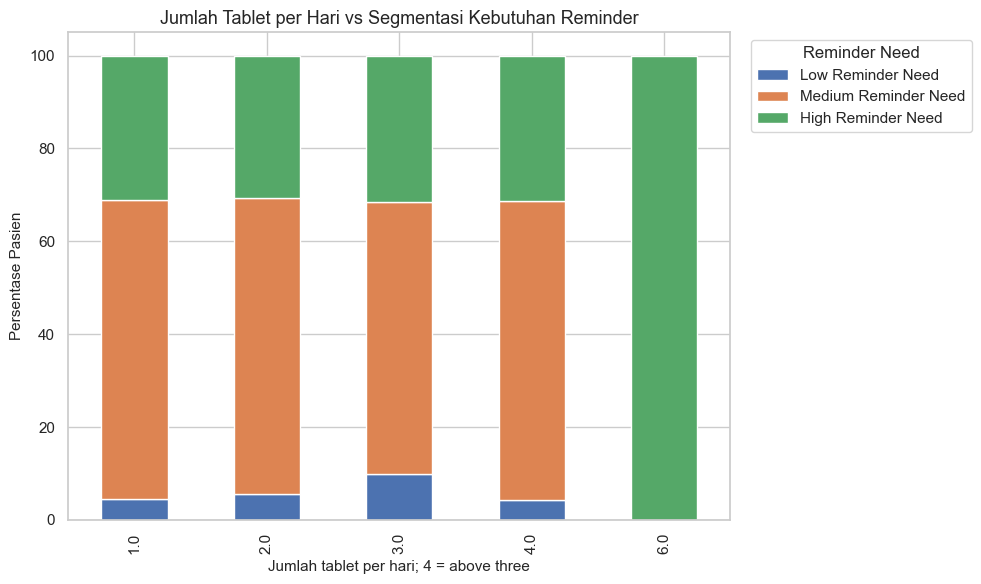

In [23]:
ct_tablets = pd.crosstab(
    eda_df['tablets_per_day_num'],
    eda_df['reminder_need_segment'],
    normalize='index'
).reindex(columns=reminder_order) * 100

display(ct_tablets.round(2))

ax = ct_tablets.plot(kind='bar', stacked=True, figsize=(10, 6))
ax.set_title('Jumlah Tablet per Hari vs Segmentasi Kebutuhan Reminder')
ax.set_xlabel('Jumlah tablet per hari; 4 = above three')
ax.set_ylabel('Persentase Pasien')
ax.legend(title='Reminder Need', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Interpretasi:**

Analisis ini melihat apakah beban obat berkaitan dengan kebutuhan reminder. Pasien dengan lebih banyak obat atau tablet per hari dapat memiliki regimen yang lebih kompleks sehingga membutuhkan reminder yang lebih kuat dan lebih terstruktur.

## 11. Segmentasi Kebutuhan Reminder

,count,percentage
reminder_need_segment,,
Low Reminder Need,38,6.24
Medium Reminder Need,383,62.89
High Reminder Need,188,30.87


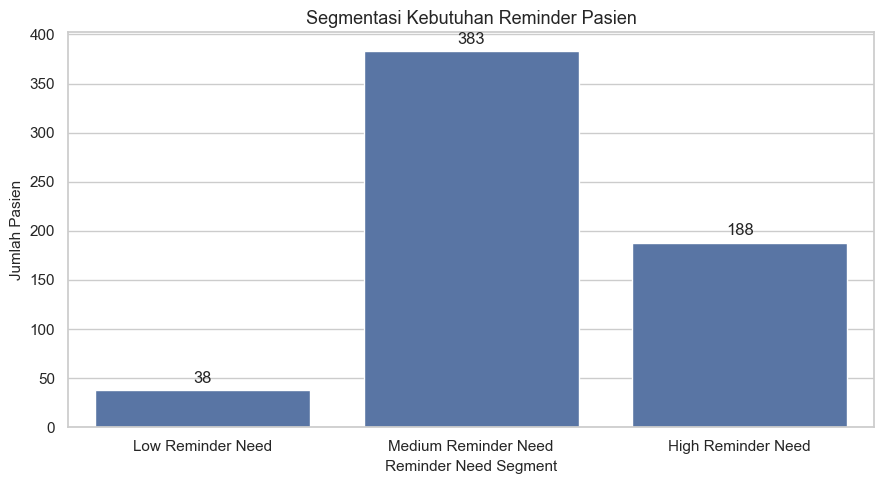

In [24]:
segment_counts = eda_df['reminder_need_segment'].value_counts().reindex(reminder_order)
segment_pct = (eda_df['reminder_need_segment'].value_counts(normalize=True).reindex(reminder_order) * 100).round(2)
segment_summary = pd.DataFrame({'count': segment_counts, 'percentage': segment_pct})
display(segment_summary)

plt.figure(figsize=(9, 5))
ax = sns.countplot(data=eda_df, x='reminder_need_segment', order=reminder_order, color=DEFAULT_COLOR)
ax.set_title('Segmentasi Kebutuhan Reminder Pasien')
ax.set_xlabel('Reminder Need Segment')
ax.set_ylabel('Jumlah Pasien')
add_bar_labels(ax)
plt.tight_layout()
plt.show()


**Interpretasi:**

Segmentasi ini dapat digunakan sebagai dasar personalisasi fitur:

- **Low Reminder Need:** reminder standar.
- **Medium Reminder Need:** reminder rutin dengan notifikasi ulang.
- **High Reminder Need:** reminder intensif dan notifikasi ke caregiver/family monitoring.

## 12. Caregiver dan Family Monitoring

,count
caregiver_group,
Spouse,270
Children,176
Parent,89
Relatives,33
Others,25
Unknown,14
Self,2


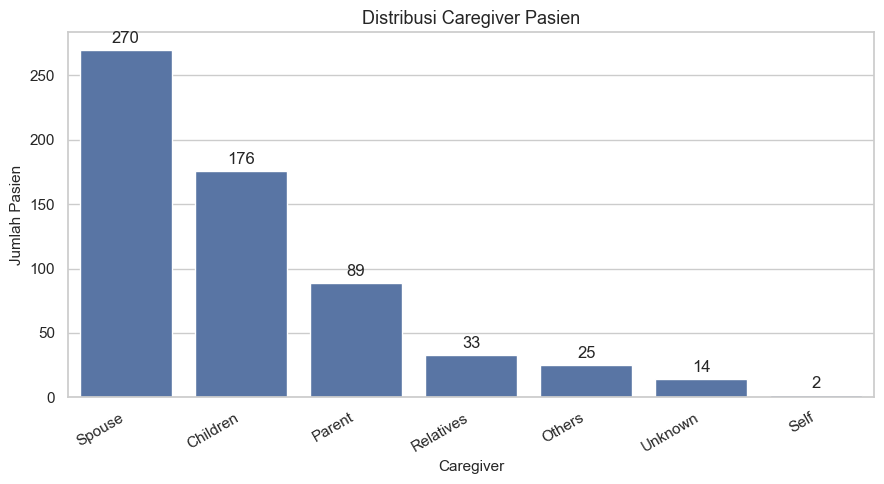

In [25]:
caregiver_plot_df = eda_df.copy()
caregiver_plot_df['caregiver_group'] = caregiver_plot_df['caregiver_group'].fillna('Unknown').astype(str)

caregiver_counts = caregiver_plot_df['caregiver_group'].value_counts()
display(caregiver_counts.to_frame('count'))

plt.figure(figsize=(9, 5))
ax = sns.countplot(
    data=caregiver_plot_df,
    x='caregiver_group',
    order=caregiver_counts.index.tolist(),
    color=DEFAULT_COLOR
)
ax.set_title('Distribusi Caregiver Pasien')
ax.set_xlabel('Caregiver')
ax.set_ylabel('Jumlah Pasien')
plt.xticks(rotation=30, ha='right')
add_bar_labels(ax)
plt.tight_layout()
plt.show()


reminder_need_segment,Low Reminder Need,Medium Reminder Need,High Reminder Need
caregiver_group,,,
Children,6.82,61.36,31.82
Others,16.00,60.00,24.00
Parent,7.87,59.55,32.58
Relatives,6.06,63.64,30.30
Self,50.00,50.00,0.00
Spouse,4.07,65.93,30.00
Unknown,7.14,50.00,42.86


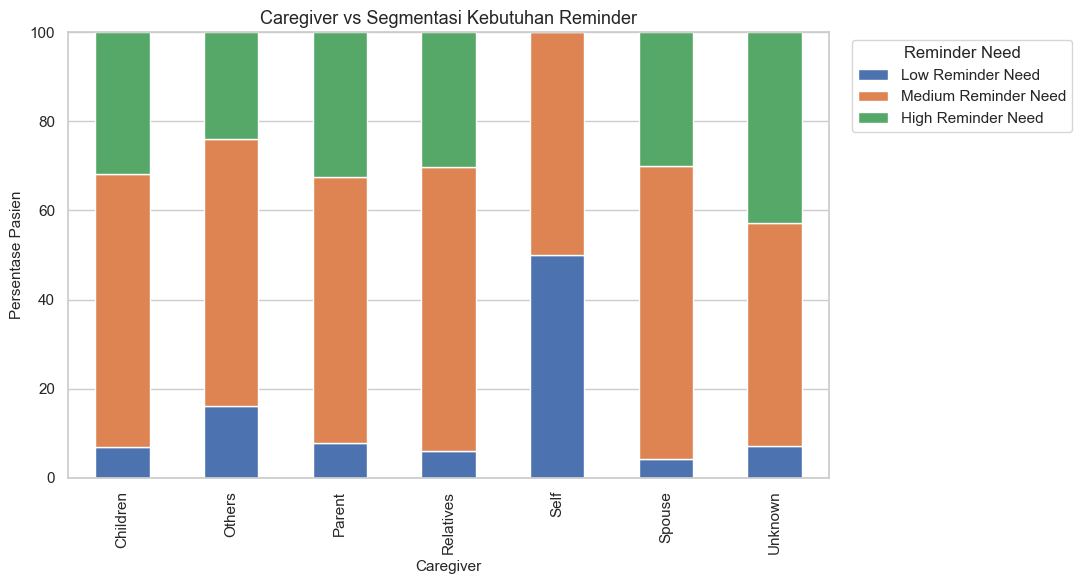

In [26]:
caregiver_analysis_df = eda_df.copy()
caregiver_analysis_df['caregiver_group'] = caregiver_analysis_df['caregiver_group'].fillna('Unknown').astype(str)

ct_caregiver = pd.crosstab(
    caregiver_analysis_df['caregiver_group'],
    caregiver_analysis_df['reminder_need_segment'],
    normalize='index'
).reindex(columns=reminder_order) * 100

display(ct_caregiver.round(2))

ax = ct_caregiver.plot(kind='bar', stacked=True, figsize=(11, 6))
ax.set_title('Caregiver vs Segmentasi Kebutuhan Reminder')
ax.set_xlabel('Caregiver')
ax.set_ylabel('Persentase Pasien')
ax.legend(title='Reminder Need', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Interpretasi:**

Jika kelompok pasien dengan caregiver tertentu memiliki proporsi medium/high reminder need yang tinggi, maka fitur family monitoring semakin relevan. Caregiver dapat menerima notifikasi jika pasien belum menandai obat sebagai sudah diminum.

## 13. Kesiapan Mobile Reminder

,count,percentage
has_mobile_phone,,
Punya HP,513,84.24
NaN,87,14.29
Tidak punya HP,9,1.48


,count,percentage
accept_mobile_app_binary,,
Menerima,394,64.70
NaN,151,24.79
Tidak menerima,64,10.51


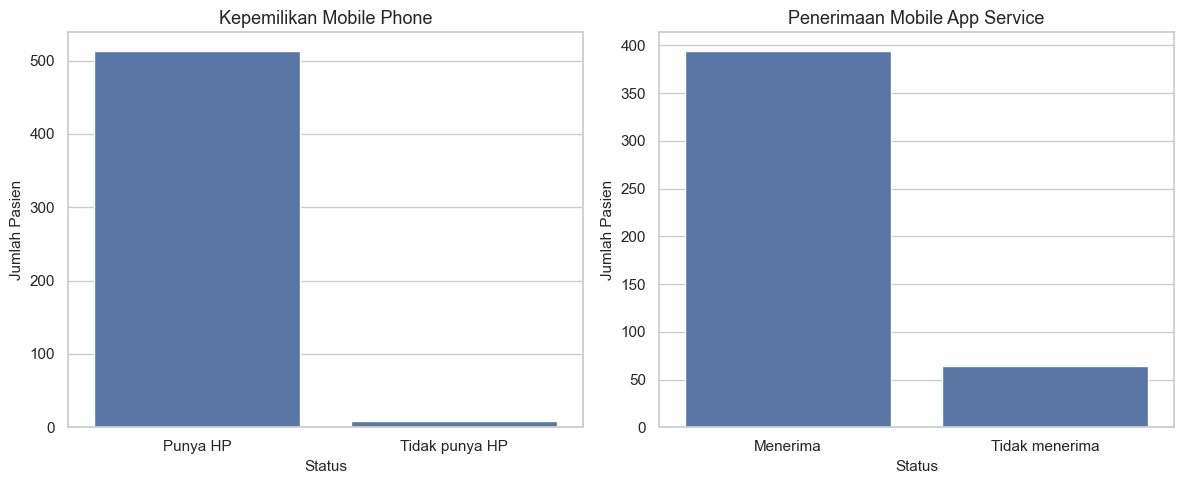

In [27]:
mobile_table = percent_table(eda_df['has_mobile_phone'].map({0: 'Tidak punya HP', 1: 'Punya HP'}))
accept_table = percent_table(eda_df['accept_mobile_app_binary'].map({0: 'Tidak menerima', 1: 'Menerima'}))

display(mobile_table)
display(accept_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=eda_df, x=eda_df['has_mobile_phone'].map({0: 'Tidak punya HP', 1: 'Punya HP'}), order=['Punya HP', 'Tidak punya HP'], ax=axes[0], color=DEFAULT_COLOR)
axes[0].set_title('Kepemilikan Mobile Phone')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Pasien')

sns.countplot(data=eda_df, x=eda_df['accept_mobile_app_binary'].map({0: 'Tidak menerima', 1: 'Menerima'}), order=['Menerima', 'Tidak menerima'], ax=axes[1], color=DEFAULT_COLOR)
axes[1].set_title('Penerimaan Mobile App Service')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Jumlah Pasien')

plt.tight_layout()
plt.show()


,indicator,agree_count,valid_response,agree_pct
0,Setuju orang bisa lupa minum obat,372,458,81.22
1,Setuju bisa lupa waktu/dosis/frekuensi,343,462,74.24
2,Setuju alert/call/SMS membantu,370,464,79.74
3,Setuju pesan motivasi membantu,388,463,83.80
4,Setuju stakeholder perlu adaptasi layanan,375,462,81.17


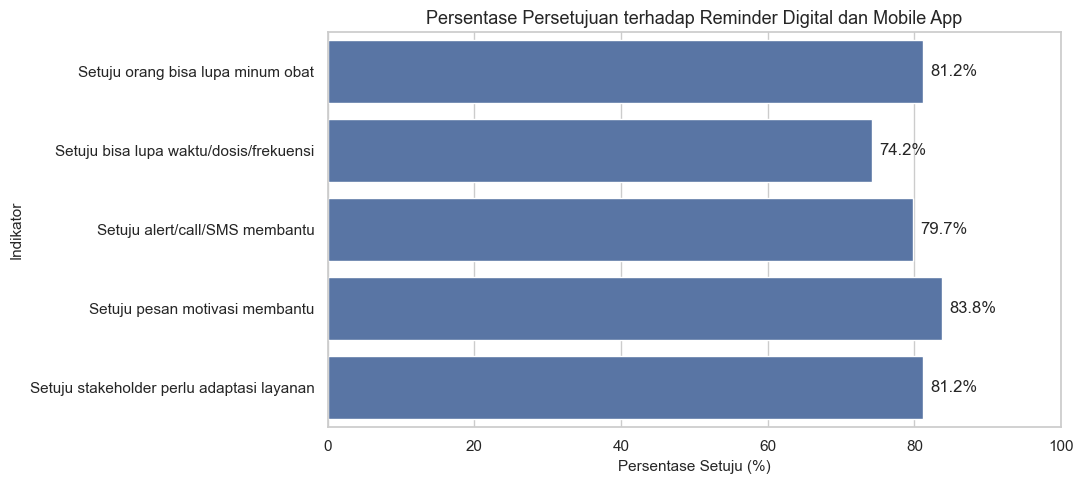

In [28]:
support_cols = {
    'people_forget_drug_statement_agree_flag': 'Setuju orang bisa lupa minum obat',
    'possible_forget_time_dose_frequency_agree_flag': 'Setuju bisa lupa waktu/dosis/frekuensi',
    'alert_call_sms_help_agree_flag': 'Setuju alert/call/SMS membantu',
    'motivational_message_help_agree_flag': 'Setuju pesan motivasi membantu',
    'stakeholder_adopt_app_agree_flag': 'Setuju stakeholder perlu adaptasi layanan'
}

support_summary = []
for col, label in support_cols.items():
    if col in eda_df.columns:
        valid = eda_df[col].dropna()
        support_summary.append({
            'indicator': label,
            'agree_count': int((valid == 1).sum()),
            'valid_response': int(valid.shape[0]),
            'agree_pct': round((valid == 1).mean() * 100, 2) if valid.shape[0] > 0 else np.nan
        })

support_summary = pd.DataFrame(support_summary)
display(support_summary)

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=support_summary, x='agree_pct', y='indicator', color=DEFAULT_COLOR)
ax.set_title('Persentase Persetujuan terhadap Reminder Digital dan Mobile App')
ax.set_xlabel('Persentase Setuju (%)')
ax.set_ylabel('Indikator')
for i, value in enumerate(support_summary['agree_pct']):
    ax.text(value + 1, i, f'{value:.1f}%', va='center')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


**Interpretasi:**

Kepemilikan mobile phone dan penerimaan mobile app menjadi indikator kesiapan implementasi fitur reminder digital. Persetujuan terhadap alert, voice call, SMS, atau pesan edukatif dapat memperkuat alasan produk untuk menyediakan notifikasi obat.

## 14. Analisis Pendukung: Lupa Obat vs Tingkat Adherence

Bagian ini hanya digunakan sebagai analisis pendukung agar EDA lupa obat tidak duplikat dengan EDA medication adherence utama.

NON ADHERENT LEVEL,high adherent,high non-adherent,low adherent,medium adherent
forget_med_flag,,,,
Pernah lupa,0.00,12.68,5.63,81.69
Tidak lupa,1.19,1.19,51.19,46.43


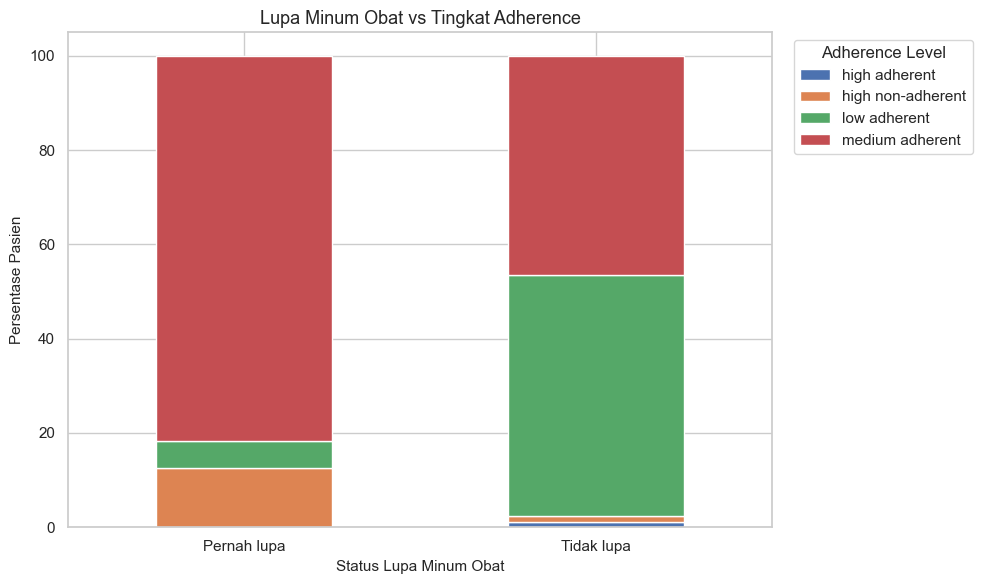

In [29]:
adherence_data = eda_df.dropna(subset=['NON ADHERENT LEVEL', 'forget_med_flag']).copy()

if len(adherence_data) > 0:
    ct_adherence = pd.crosstab(
        adherence_data['forget_med_flag'].map({0: 'Tidak lupa', 1: 'Pernah lupa'}),
        adherence_data['NON ADHERENT LEVEL'],
        normalize='index'
    ) * 100
    display(ct_adherence.round(2))

    ax = ct_adherence.plot(kind='bar', stacked=True, figsize=(10, 6))
    ax.set_title('Lupa Minum Obat vs Tingkat Adherence')
    ax.set_xlabel('Status Lupa Minum Obat')
    ax.set_ylabel('Persentase Pasien')
    ax.legend(title='Adherence Level', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada data cukup untuk analisis adherence level.')


**Interpretasi:**

Analisis ini membantu melihat apakah pasien yang lupa minum obat cenderung berada pada level adherence tertentu. Namun, fokus utama notebook tetap pada risiko lupa obat dan kebutuhan reminder.

## 15. Main Findings

In [30]:
def get_pct(flag_col):
    valid = eda_df[flag_col].dropna()
    if len(valid) == 0:
        return np.nan
    return round((valid == 1).mean() * 100, 2)

findings = pd.DataFrame([
    {'temuan': 'Pasien pernah lupa minum obat sesuai resep', 'persentase': get_pct('forget_med_flag')},
    {'temuan': 'Pasien lupa membawa obat saat bepergian', 'persentase': get_pct('travel_forget_flag')},
    {'temuan': 'Pasien kesulitan mengingat konsumsi obat', 'persentase': get_pct('memory_difficulty_flag')},
    {'temuan': 'Pasien membutuhkan reminder eksternal', 'persentase': get_pct('external_reminder_needed')},
    {'temuan': 'Pasien memiliki kecenderungan lupa umum', 'persentase': get_pct('high_general_forgetfulness_flag')},
    {'temuan': 'Pasien menerima penggunaan mobile app', 'persentase': get_pct('accept_mobile_app_binary')},
])

display(findings)


,temuan,persentase
0,Pasien pernah lupa minum obat sesuai resep,44.76
1,Pasien lupa membawa obat saat bepergian,51.77
2,Pasien kesulitan mengingat konsumsi obat,70.91
3,Pasien membutuhkan reminder eksternal,59.60
4,Pasien memiliki kecenderungan lupa umum,77.46
5,Pasien menerima penggunaan mobile app,86.03


Ringkasan temuan utama dapat digunakan untuk menjawab business questions dan menjembatani hasil EDA dengan fitur Teman Pulih.

## 16. Product Implication untuk Teman Pulih

In [31]:
product_implication = pd.DataFrame([
    {
        'Temuan EDA': 'Pasien pernah lupa minum obat',
        'Implikasi Fitur': 'Reminder otomatis berdasarkan jadwal obat yang sudah dikonfirmasi user'
    },
    {
        'Temuan EDA': 'Pasien lupa membawa obat saat bepergian',
        'Implikasi Fitur': 'Reminder tambahan pada waktu kritis dan checklist obat harian'
    },
    {
        'Temuan EDA': 'Pasien membutuhkan reminder eksternal',
        'Implikasi Fitur': 'Push notification, SMS/call fallback, dan notifikasi ulang'
    },
    {
        'Temuan EDA': 'Pasien mengandalkan keluarga/caregiver',
        'Implikasi Fitur': 'Family monitoring untuk memantau status sudah/belum minum obat'
    },
    {
        'Temuan EDA': 'Pasien dengan high reminder need',
        'Implikasi Fitur': 'Eskalasi reminder ke caregiver jika obat belum ditandai diminum'
    },
    {
        'Temuan EDA': 'Pasien menerima mobile app service',
        'Implikasi Fitur': 'Reminder digital layak dijadikan fitur utama aplikasi'
    }
])

display(product_implication)


,Temuan EDA,Implikasi Fitur
0,Pasien pernah lupa minum obat,Reminder otomatis berdasarkan jadwal obat yang...
1,Pasien lupa membawa obat saat bepergian,Reminder tambahan pada waktu kritis dan checkl...
2,Pasien membutuhkan reminder eksternal,"Push notification, SMS/call fallback, dan noti..."
3,Pasien mengandalkan keluarga/caregiver,Family monitoring untuk memantau status sudah/...
4,Pasien dengan high reminder need,Eskalasi reminder ke caregiver jika obat belum...
5,Pasien menerima mobile app service,Reminder digital layak dijadikan fitur utama a...


## 17. Kesimpulan

EDA ini menunjukkan bahwa risiko lupa konsumsi obat dapat dianalisis melalui beberapa indikator, yaitu lupa minum obat sesuai resep, lupa membawa obat saat bepergian, kesulitan mengingat jadwal obat, kecenderungan lupa umum, dan kebutuhan reminder eksternal.

Berdasarkan indikator tersebut, pasien dapat dikelompokkan menjadi segmen kebutuhan reminder rendah, sedang, dan tinggi. Segmentasi ini dapat digunakan oleh Teman Pulih untuk merancang fitur reminder yang lebih adaptif:

- Reminder standar untuk pasien dengan kebutuhan rendah.
- Reminder rutin dan notifikasi ulang untuk pasien dengan kebutuhan sedang.
- Reminder intensif dan family monitoring/caregiver alert untuk pasien dengan kebutuhan tinggi.

Dengan demikian, hasil EDA ini mendukung pengembangan fitur pengingat minum obat dan pemantauan keluarga pada aplikasi Teman Pulih.

## 18. Export Dataset Bersih untuk Dashboard Streamlit

In [32]:
OUTPUT_CLEANED_CSV = DATASET_PATH.parent / 'cleaned_EDA_Lupa_Konsumsi_Obat.csv'
OUTPUT_DATA_DICTIONARY_CSV = DATASET_PATH.parent / 'data_dictionary_EDA_Lupa_Konsumsi_Obat.csv'

eda_df.to_csv(OUTPUT_CLEANED_CSV, index=False)
data_dictionary.to_csv(OUTPUT_DATA_DICTIONARY_CSV, index=False)

print('Cleaned dataset berhasil disimpan ke:')
print(OUTPUT_CLEANED_CSV)
print('\nData dictionary berhasil disimpan ke:')
print(OUTPUT_DATA_DICTIONARY_CSV)


Cleaned dataset berhasil disimpan ke:
D:\Icun\Dicoding\DBS Coding Camp\Capstone Project\Dataset\cleaned_EDA_Lupa_Konsumsi_Obat.csv

Data dictionary berhasil disimpan ke:
D:\Icun\Dicoding\DBS Coding Camp\Capstone Project\Dataset\data_dictionary_EDA_Lupa_Konsumsi_Obat.csv
